In [31]:
# IMPORTS
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import joblib

from pathlib import Path

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
)

In [46]:
# Path to RF algo: data/home/cnairy/random_forest_phase_output_highres/random_forest_cloud_phase_highres.joblib

# ============================================================
# User settings
# ============================================================

NEW_DATE = "20150613"

# Saved Random Forest model from training
RF_MODEL_FILE = Path("/data/home/cnairy/random_forest_phase_output_highres/random_forest_cloud_phase_highres.joblib")

# June 13, 2015 input files
RADAR_FILE = Path("/data/home/cnairy/13june2015_data/data_refl_radar_20150613.nc")
CEIL_FILE = Path("/data/home/cnairy/13june2015_data/data_ceilometer20150613.nc")
LABEL_FILE = Path("/data/home/cnairy/13june2015_data/cloud_phase_label_20150613.nc")

VEL_FILE = Path("/data/home/cnairy/13june2015_data/mean_doppler_vel_radar_20150613.nc")
MWR_FILE = Path("/data/home/cnairy/13june2015_data/lwp_mwr_20150613.nc")
SPEC_FILE = Path("/data/home/cnairy/13june2015_data/spectral_width_radar_20150613.nc")

# Separate output directory for June 13 testing
OUT_DIR = Path("random_forest_phase_output_highres_20150613")
OUT_DIR.mkdir(parents=True, exist_ok=True)

FIG_DIR = OUT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42


In [47]:
# ============================================================
# Load saved Random Forest model
# ============================================================

rf_saved = joblib.load(RF_MODEL_FILE)

print("Loaded saved Random Forest model:")
print(rf_saved)

if hasattr(rf_saved, "feature_names_in_"):
    print("\nFeatures expected by saved model:")
    print(list(rf_saved.feature_names_in_))
else:
    print("\nSaved model does not include feature_names_in_.")
    print("Make sure feature_cols exactly matches the training notebook.")

Loaded saved Random Forest model:
{'model': RandomForestClassifier(class_weight='balanced', min_samples_leaf=10,
                       n_estimators=500, n_jobs=-1, random_state=42), 'feature_cols': ['reflectivity', 'backscatter', 'velocity', 'spectral_width', 'liq', 'height'], 'class_names': [0, 1, 2, 3, 4]}

Saved model does not include feature_names_in_.
Make sure feature_cols exactly matches the training notebook.


In [48]:
# ============================================================
# Open June 13 datasets
# ============================================================

radar_ds = xr.open_dataset(RADAR_FILE)
ceil_ds = xr.open_dataset(CEIL_FILE)
label_ds = xr.open_dataset(LABEL_FILE)

vel_ds = xr.open_dataset(VEL_FILE)
mwr_lwp_ds = xr.open_dataset(MWR_FILE)
spec_width_ds = xr.open_dataset(SPEC_FILE)

print("Radar dataset:")
print(radar_ds)

print("\nCeilometer dataset:")
print(ceil_ds)

print("\nLabel dataset:")
print(label_ds)

print("\nVelocity dataset:")
print(vel_ds)

print("\nMWR LWP dataset:")
print(mwr_lwp_ds)

print("\nSpectrum width dataset:")
print(spec_width_ds)

Radar dataset:
<xarray.Dataset> Size: 14MB
Dimensions:                     (height: 596, time: 2880)
Coordinates:
  * height                      (height) float32 2kB 160.0 190.0 ... 1.801e+04
  * time                        (time) datetime64[ns] 23kB 2015-06-13 ... 201...
Data variables:
    reflectivity_best_estimate  (time, height) float64 14MB ...

Ceilometer dataset:
<xarray.Dataset> Size: 6MB
Dimensions:      (height: 252, time: 2880)
Coordinates:
  * height       (height) float32 1kB 15.0 45.0 75.0 ... 7.515e+03 7.545e+03
  * time         (time) datetime64[ns] 23kB 2015-06-13 ... 2015-06-13T23:59:30
Data variables:
    backscatter  (time, height) float64 6MB ...

Label dataset:
<xarray.Dataset> Size: 7MB
Dimensions:            (height: 596, time: 2880)
Coordinates:
  * height             (height) float32 2kB 0.16 0.19 0.22 ... 17.95 17.98 18.01
  * time               (time) datetime64[ns] 23kB 2015-06-13 ... 2015-06-13T2...
Data variables:
    cloud_phase_mplgr  (time, height) f

In [49]:
ceil_ds['backscatter'].values

array([[0.27875361, 0.45229772, 0.25527251, ...,        nan, 2.54423356,
               nan],
       [0.2899196 , 0.42186312, 0.27271553, ...,        nan, 2.47996229,
        1.91805418],
       [0.34277068, 0.42322036, 0.22610709, ..., 1.98324066, 2.10298601,
               nan],
       ...,
       [0.85732788, 0.85632488, 0.76588845, ...,        nan,        nan,
               nan],
       [0.88624708, 0.86530143, 0.74979897, ...,        nan,        nan,
               nan],
       [0.86783764, 0.85287812, 0.74278752, ...,        nan,        nan,
               nan]])

In [50]:
# ============================================================
# Define variable names
# ============================================================

radar_var = "reflectivity_best_estimate"
ceil_var = "backscatter"
label_var = "cloud_phase_mplgr"

vel_var = "mean_doppler_velocity"
mwr_lwp_var = "liq"
spec_width_var = "spectral_width"

print("Radar variable exists:", radar_var in radar_ds)
print("Ceilometer variable exists:", ceil_var in ceil_ds)
print("Label variable exists:", label_var in label_ds)
print("Velocity variable exists:", vel_var in vel_ds)
print("MWR LWP variable exists:", mwr_lwp_var in mwr_lwp_ds)
print("Spectrum width variable exists:", spec_width_var in spec_width_ds)

print("\nRadar variables:")
print(list(radar_ds.data_vars))

print("\nCeilometer variables:")
print(list(ceil_ds.data_vars))

print("\nLabel variables:")
print(list(label_ds.data_vars))

print("\nVelocity variables:")
print(list(vel_ds.data_vars))

print("\nMWR variables:")
print(list(mwr_lwp_ds.data_vars))

print("\nSpectrum width variables:")
print(list(spec_width_ds.data_vars))

Radar variable exists: True
Ceilometer variable exists: True
Label variable exists: True
Velocity variable exists: True
MWR LWP variable exists: True
Spectrum width variable exists: True

Radar variables:
['reflectivity_best_estimate']

Ceilometer variables:
['backscatter']

Label variables:
['cloud_phase_mplgr']

Velocity variables:
['mean_doppler_velocity']

MWR variables:
['liq']

Spectrum width variables:
['spectral_width']


In [51]:
# ============================================================
# Fix label height coordinate units
# ============================================================

label_on_radar_grid = label_ds[label_var].copy()

# Convert label height from km to m
label_on_radar_grid = label_on_radar_grid.assign_coords(
    height=label_on_radar_grid["height"] * 1000.0
)

# Match height dtype to radar height dtype
label_on_radar_grid = label_on_radar_grid.assign_coords(
    height=label_on_radar_grid["height"].astype(radar_ds[radar_var]["height"].dtype)
)

print(label_on_radar_grid)

<xarray.DataArray 'cloud_phase_mplgr' (time: 2880, height: 596)> Size: 7MB
[1716480 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 23kB 2015-06-13 ... 2015-06-13T23:59:30
  * height   (height) float32 2kB 160.0 190.0 220.0 ... 1.798e+04 1.801e+04


In [52]:
# ============================================================
# Diagnose why backscatter is 100% missing
# ============================================================

print("Ceilometer dataset:")
print(ceil_ds)

print("\nCeilometer variables:")
print(list(ceil_ds.data_vars))

print("\nCurrent ceil_var:")
print(ceil_var)

print("\nDoes ceil_var exist?")
print(ceil_var in ceil_ds.data_vars)

print("\nCeilometer backscatter DataArray:")
print(ceil_ds[ceil_var])

print("\nOriginal ceilometer backscatter missing values:")
print(ceil_ds[ceil_var].isnull().sum().values)

print("\nOriginal ceilometer backscatter total values:")
print(ceil_ds[ceil_var].size)

print("\nOriginal ceilometer backscatter percent missing:")
print(float(ceil_ds[ceil_var].isnull().sum() / ceil_ds[ceil_var].size * 100))

print("\nOriginal ceilometer backscatter min/max:")
print(ceil_ds[ceil_var].min(skipna=True).values)
print(ceil_ds[ceil_var].max(skipna=True).values)

print("\nCeilometer dims:")
print(ceil_ds[ceil_var].dims)

print("\nCeilometer coords:")
print(ceil_ds[ceil_var].coords)

print("\nRadar time range:")
print(radar_ds["time"].min().values, radar_ds["time"].max().values)

print("\nCeilometer time range:")
print(ceil_ds["time"].min().values, ceil_ds["time"].max().values)

print("\nRadar height range:")
print(radar_ds["height"].min().values, radar_ds["height"].max().values)

print("\nCeilometer height range:")
print(ceil_ds["height"].min().values, ceil_ds["height"].max().values)

Ceilometer dataset:
<xarray.Dataset> Size: 6MB
Dimensions:      (height: 252, time: 2880)
Coordinates:
  * height       (height) float32 1kB 15.0 45.0 75.0 ... 7.515e+03 7.545e+03
  * time         (time) datetime64[ns] 23kB 2015-06-13 ... 2015-06-13T23:59:30
Data variables:
    backscatter  (time, height) float64 6MB 0.2788 0.4523 0.2553 ... nan nan nan

Ceilometer variables:
['backscatter']

Current ceil_var:
backscatter

Does ceil_var exist?
True

Ceilometer backscatter DataArray:
<xarray.DataArray 'backscatter' (time: 2880, height: 252)> Size: 6MB
array([[0.278754, 0.452298, 0.255273, ...,      nan, 2.544234,      nan],
       [0.28992 , 0.421863, 0.272716, ...,      nan, 2.479962, 1.918054],
       [0.342771, 0.42322 , 0.226107, ..., 1.983241, 2.102986,      nan],
       ...,
       [0.857328, 0.856325, 0.765888, ...,      nan,      nan,      nan],
       [0.886247, 0.865301, 0.749799, ...,      nan,      nan,      nan],
       [0.867838, 0.852878, 0.742788, ...,      nan,      nan

In [70]:
# ============================================================
# Load saved Random Forest model
# ============================================================

rf_saved = joblib.load(RF_MODEL_FILE)

print("Loaded saved Random Forest model:")
print(rf_saved)

if hasattr(rf_saved, "feature_names_in_"):
    feature_cols = list(rf_saved.feature_names_in_)
    print("\nFeatures expected by saved model:")
    print(feature_cols)
else:
    feature_cols = [
        "reflectivity",
        "backscatter",
        "velocity",
        "spectral_width",
        "liq",
        "height",
    ]
    print("\nSaved model does not include feature_names_in_.")
    print("Using manually defined feature_cols:")
    print(feature_cols)

Loaded saved Random Forest model:
{'model': RandomForestClassifier(class_weight='balanced', min_samples_leaf=10,
                       n_estimators=500, n_jobs=-1, random_state=42), 'feature_cols': ['reflectivity', 'backscatter', 'velocity', 'spectral_width', 'liq', 'height'], 'class_names': [0, 1, 2, 3, 4]}

Saved model does not include feature_names_in_.
Using manually defined feature_cols:
['reflectivity', 'backscatter', 'velocity', 'spectral_width', 'liq', 'height']


In [71]:
# ============================================================
# Put June 13 variables onto radar grid
# ============================================================

ref_time = radar_ds["time"]
ref_height = radar_ds["height"]

# Work directly with DataArrays
ceil_on_radar_grid = ceil_ds[ceil_var].sortby("time").sortby("height").interp(
    time=ref_time,
    height=ref_height,
    method="nearest"
)

vel_on_radar_grid = vel_ds[vel_var].sortby("time").sortby("height").interp(
    time=ref_time,
    height=ref_height,
    method="nearest"
)

spec_width_on_radar_grid = spec_width_ds[spec_width_var].sortby("time").sortby("height").interp(
    time=ref_time,
    height=ref_height,
    method="nearest"
)

mwr_lwp_on_radar_time = mwr_lwp_ds[mwr_lwp_var].sortby("time").interp(
    time=ref_time,
    method="nearest"
)

# Label grid
label_on_radar_grid = label_ds[label_var].copy()

# Convert label height from km to m if needed
if float(label_on_radar_grid["height"].max()) < 100 and float(ref_height.max()) > 1000:
    label_on_radar_grid = label_on_radar_grid.assign_coords(
        height=label_on_radar_grid["height"] * 1000.0
    )

label_on_radar_grid = label_on_radar_grid.assign_coords(
    height=label_on_radar_grid["height"].astype(ref_height.dtype)
)

label_on_radar_grid = label_on_radar_grid.sortby("time").sortby("height").interp(
    time=ref_time,
    height=ref_height,
    method="nearest"
)

print("Shapes after interpolation:")
print("Reflectivity:", radar_ds[radar_var].shape)
print("Backscatter:", ceil_on_radar_grid.shape)
print("Velocity:", vel_on_radar_grid.shape)
print("Spectrum width:", spec_width_on_radar_grid.shape)
print("LWP:", mwr_lwp_on_radar_time.shape)
print("Label:", label_on_radar_grid.shape)

print("\nNaNs after interpolation:")
print("Reflectivity:", radar_ds[radar_var].isnull().sum().values)
print("Backscatter:", ceil_on_radar_grid.isnull().sum().values)
print("Velocity:", vel_on_radar_grid.isnull().sum().values)
print("Spectrum width:", spec_width_on_radar_grid.isnull().sum().values)
print("LWP:", mwr_lwp_on_radar_time.isnull().sum().values)
print("Label:", label_on_radar_grid.isnull().sum().values)

Shapes after interpolation:
Reflectivity: (2880, 596)
Backscatter: (2880, 596)
Velocity: (2880, 596)
Spectrum width: (2880, 596)
LWP: (2880,)
Label: (2880, 596)

NaNs after interpolation:
Reflectivity: 1062527
Backscatter: 1397562
Velocity: 1062527
Spectrum width: 1062527
LWP: 0
Label: 0


In [72]:
# ============================================================
# Fix label height coordinate if needed
# ============================================================

label_on_radar_grid = label_ds[label_var].copy()

radar_height_max = float(radar_ds[radar_var]["height"].max())
label_height_max = float(label_on_radar_grid["height"].max())

print("Radar max height:", radar_height_max)
print("Label max height:", label_height_max)

# If label height looks like km while radar height is meters, convert labels to meters
if label_height_max < 100 and radar_height_max > 1000:
    print("Converting label height from km to m.")
    label_on_radar_grid = label_on_radar_grid.assign_coords(
        height=label_on_radar_grid["height"] * 1000.0
    )

# Match height dtype to radar height dtype
label_on_radar_grid = label_on_radar_grid.assign_coords(
    height=label_on_radar_grid["height"].astype(radar_ds[radar_var]["height"].dtype)
)

print(label_on_radar_grid)

Radar max height: 18010.0
Label max height: 18.010000228881836
Converting label height from km to m.
<xarray.DataArray 'cloud_phase_mplgr' (time: 2880, height: 596)> Size: 7MB
[1716480 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 23kB 2015-06-13 ... 2015-06-13T23:59:30
  * height   (height) float32 2kB 160.0 190.0 220.0 ... 1.798e+04 1.801e+04


In [74]:
# ============================================================
# Combine June 13 predictor variables and labels
# ============================================================

combined_ds = xr.Dataset()

combined_ds["reflectivity"] = radar_ds[radar_var]
combined_ds["backscatter"] = ceil_on_radar_grid
combined_ds["velocity"] = vel_on_radar_grid
combined_ds["spectral_width"] = spec_width_on_radar_grid
combined_ds["liq"] = mwr_lwp_on_radar_time

# Include labels since you have a June 13 label file
combined_ds["cloud_phase_mplgr"] = label_on_radar_grid

print(combined_ds)

<xarray.Dataset> Size: 62MB
Dimensions:            (height: 596, time: 2880)
Coordinates:
  * height             (height) float32 2kB 160.0 190.0 ... 1.798e+04 1.801e+04
  * time               (time) datetime64[ns] 23kB 2015-06-13 ... 2015-06-13T2...
Data variables:
    reflectivity       (time, height) float64 14MB nan nan nan ... nan nan nan
    backscatter        (time, height) float64 14MB 0.2304 0.195 ... nan nan
    velocity           (time, height) float64 14MB nan nan nan ... nan nan nan
    spectral_width     (time, height) float64 14MB nan nan nan ... nan nan nan
    liq                (time) float32 12kB 0.00523 0.005186 ... 0.0095 0.01035
    cloud_phase_mplgr  (time, height) float32 7MB 0.0 0.0 0.0 ... 0.0 0.0 0.0


In [75]:
# ============================================================
# Define feature columns used by the saved Random Forest
# ============================================================

label_col = "cloud_phase_mplgr"

# Use the feature names stored in the saved RF model if available
if "rf_saved" in globals() and hasattr(rf_saved, "feature_names_in_"):
    feature_cols = list(rf_saved.feature_names_in_)
else:
    feature_cols = [
        "reflectivity",
        "backscatter",
        "velocity",
        "spectral_width",
        "liq",
        "height",
    ]

print("Feature columns:")
print(feature_cols)

print("\nLabel column:")


Feature columns:
['reflectivity', 'backscatter', 'velocity', 'spectral_width', 'liq', 'height']

Label column:


In [76]:
# ============================================================
# Convert June 13 data to DataFrame and check values
# ============================================================

df_all = combined_ds.to_dataframe().reset_index()

label_col = "cloud_phase_mplgr"

print("Full June 13 DataFrame shape:", df_all.shape)

print("\nMissing values:")
print(df_all[feature_cols + [label_col]].isna().sum())

print("\nPercent missing:")
print((df_all[feature_cols + [label_col]].isna().mean() * 100).round(2))

print("\nObserved phase counts before dropping NaNs:")
print(df_all[label_col].value_counts(dropna=False).sort_index())

print("\nFeature columns used for prediction:")
print(feature_cols)

Full June 13 DataFrame shape: (1716480, 8)

Missing values:
reflectivity         1062527
backscatter          1397562
velocity             1062527
spectral_width       1062527
liq                        0
height                     0
cloud_phase_mplgr      31680
dtype: int64

Percent missing:
reflectivity         61.90
backscatter          81.42
velocity             61.90
spectral_width       61.90
liq                   0.00
height                0.00
cloud_phase_mplgr     1.85
dtype: float64

Observed phase counts before dropping NaNs:
cloud_phase_mplgr
0.0    1041712
1.0      68836
2.0     552273
3.0      21979
NaN      31680
Name: count, dtype: int64

Feature columns used for prediction:
['reflectivity', 'backscatter', 'velocity', 'spectral_width', 'liq', 'height']


In [77]:
# ============================================================
# Inspect saved RF object
# ============================================================

print(type(rf_saved))

if isinstance(rf_saved, dict):
    print("\nKeys in saved object:")
    print(rf_saved.keys())

# ============================================================
# Extract model information from saved dictionary
# ============================================================

rf_model = rf_saved["model"]
feature_cols = rf_saved["feature_cols"]
class_names = rf_saved["class_names"]

print("Extracted Random Forest model:")
print(rf_model)

print("\nFeature columns expected by model:")
print(feature_cols)

print("\nClass names:")
print(class_names)

<class 'dict'>

Keys in saved object:
dict_keys(['model', 'feature_cols', 'class_names'])
Extracted Random Forest model:
RandomForestClassifier(class_weight='balanced', min_samples_leaf=10,
                       n_estimators=500, n_jobs=-1, random_state=42)

Feature columns expected by model:
['reflectivity', 'backscatter', 'velocity', 'spectral_width', 'liq', 'height']

Class names:
[0, 1, 2, 3, 4]


In [78]:
# ============================================================
# Drop NaNs and apply saved Random Forest
# ============================================================

# Keep only rows with valid predictor values
model_df = df_all.dropna(subset=feature_cols).copy()

# Keep labels if available, but do not require them for prediction
if label_col in model_df.columns:
    model_df[label_col] = model_df[label_col].astype("float")

print("Shape before feature filtering:", df_all.shape)
print("Shape after feature filtering:", model_df.shape)

print("\nMissing values after filtering:")
print(model_df[feature_cols].isna().sum())

X_new = model_df[feature_cols]

# Predict cloud phase
model_df["phase_pred"] = rf_model.predict(X_new).astype(int)

# Add probabilities if available
if hasattr(rf_model, "predict_proba"):
    pred_probs = rf_model.predict_proba(X_new)

    for i, class_value in enumerate(rf_model.classes_):
        model_df[f"prob_phase_{int(class_value)}"] = pred_probs[:, i]

print("\nPredicted phase counts:")
print(model_df["phase_pred"].value_counts(dropna=False).sort_index())

if label_col in model_df.columns:
    print("\nObserved phase counts after feature filtering:")
    print(model_df[label_col].value_counts(dropna=False).sort_index())

display(model_df.head())

Shape before feature filtering: (1716480, 8)
Shape after feature filtering: (265331, 8)

Missing values after filtering:
reflectivity      0
backscatter       0
velocity          0
spectral_width    0
liq               0
height            0
dtype: int64

Predicted phase counts:
phase_pred
0      1933
1     46214
2    200526
3     16651
4         7
Name: count, dtype: int64

Observed phase counts after feature filtering:
cloud_phase_mplgr
0.0      1931
1.0     56916
2.0    191744
3.0     12829
NaN      1911
Name: count, dtype: int64


,height,time,reflectivity,backscatter,velocity,spectral_width,liq,cloud_phase_mplgr,phase_pred,prob_phase_0,prob_phase_1,prob_phase_2,prob_phase_3,prob_phase_4
151,160.0,2015-06-13 01:15:30,-50.687927,0.381403,-1.911953,0.066557,0.00705,0.0,0,0.955063,0.034295,0.004958,0.001871,0.003813
152,160.0,2015-06-13 01:16:00,-49.409943,0.278754,-2.043717,0.097359,0.00620,0.0,0,0.947735,0.047158,0.003926,0.001181,0.000000
153,160.0,2015-06-13 01:16:30,-47.646694,0.227573,-1.260191,0.166445,0.00665,0.0,0,0.974875,0.023764,0.000800,0.000561,0.000000
156,160.0,2015-06-13 01:18:00,-40.783394,0.233409,-1.768354,0.158264,0.00630,0.0,0,0.969558,0.028206,0.001419,0.000817,0.000000
157,160.0,2015-06-13 01:18:30,-42.345591,0.322648,-1.584447,0.168139,0.00635,0.0,0,0.976013,0.018380,0.000950,0.004656,0.000000


In [79]:
# ============================================================
# Save June 13 predictions
# ============================================================

pred_csv = OUT_DIR / f"rf_cloud_phase_predictions_{NEW_DATE}.csv"
model_df.to_csv(pred_csv, index=False)

print(f"Saved predictions to: {pred_csv}")

Saved predictions to: random_forest_phase_output_highres_20150613/rf_cloud_phase_predictions_20150613.csv


June 13 classification report:
              precision    recall  f1-score   support

       Clear       0.83      0.83      0.83      1931
      Liquid       0.97      0.79      0.87     56916
         Ice       0.93      0.97      0.95    191744
       Mixed       0.49      0.64      0.56     12829
     Unknown       0.00      0.00      0.00         0

    accuracy                           0.91    263420
   macro avg       0.65      0.65      0.64    263420
weighted avg       0.92      0.91      0.91    263420



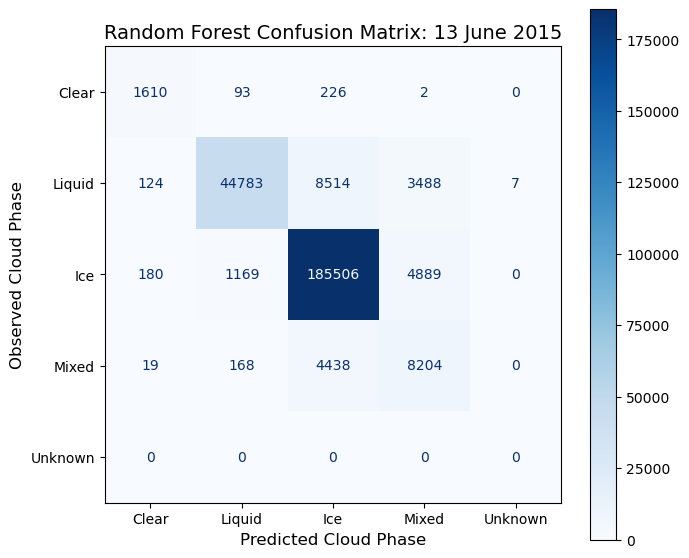

In [91]:
# ============================================================
# June 13 confusion matrix
# ============================================================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

eval_df = model_df.dropna(subset=[label_col, "phase_pred"]).copy()
eval_df[label_col] = eval_df[label_col].astype(int)
eval_df["phase_pred"] = eval_df["phase_pred"].astype(int)

phase_label_names = {
    0: "Clear",
    1: "Liquid",
    2: "Ice",
    3: "Mixed",
    4: "Unknown"
}

class_values = sorted(phase_label_names.keys())
class_names = [phase_label_names[i] for i in class_values]

y_true_new = eval_df[label_col]
y_pred_new = eval_df["phase_pred"]

print("June 13 classification report:")
print(
    classification_report(
        y_true_new,
        y_pred_new,
        labels=class_values,
        target_names=class_names,
        zero_division=0
    )
)

cm = confusion_matrix(
    y_true_new,
    y_pred_new,
    labels=class_values
)

fig, ax = plt.subplots(figsize=(7, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    ax=ax,
    cmap="Blues",
    colorbar=True,
    values_format="d"
)

ax.set_title("Random Forest Confusion Matrix: 13 June 2015", fontsize=14)
ax.set_xlabel("Predicted Cloud Phase", fontsize=12)
ax.set_ylabel("Observed Cloud Phase", fontsize=12)

plt.xticks(rotation=0)
plt.yticks(rotation=0)

fig.tight_layout()
fig.savefig(f"confusion_matrix_{NEW_DATE}.png", dpi=300, bbox_inches="tight")
plt.show()

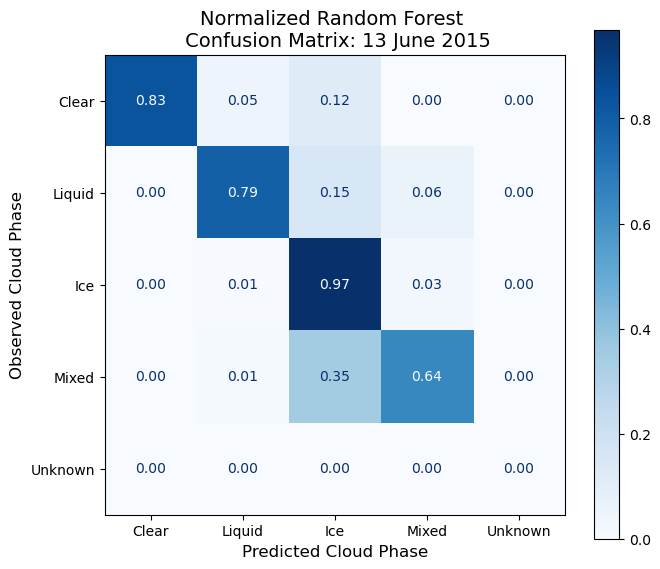

In [92]:
# ============================================================
# June 13 normalized confusion matrix
# ============================================================

cm_norm = confusion_matrix(
    y_true_new,
    y_pred_new,
    labels=class_values,
    normalize="true"
)

fig, ax = plt.subplots(figsize=(7, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_norm,
    display_labels=class_names
)

disp.plot(
    ax=ax,
    cmap="Blues",
    colorbar=True,
    values_format=".2f"
)

ax.set_title("Normalized Random Forest \n Confusion Matrix: 13 June 2015", fontsize=14)
ax.set_xlabel("Predicted Cloud Phase", fontsize=12)
ax.set_ylabel("Observed Cloud Phase", fontsize=12)

plt.xticks(rotation=0)
plt.yticks(rotation=0)

fig.tight_layout()
fig.savefig(f"confusion_matrix_normalized_{NEW_DATE}.png", dpi=300, bbox_inches="tight")
plt.show()

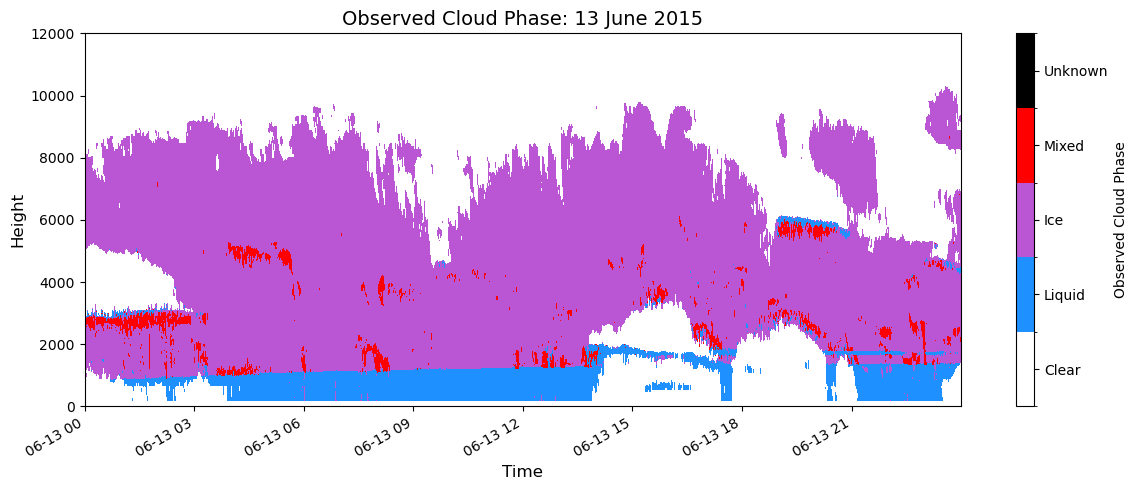

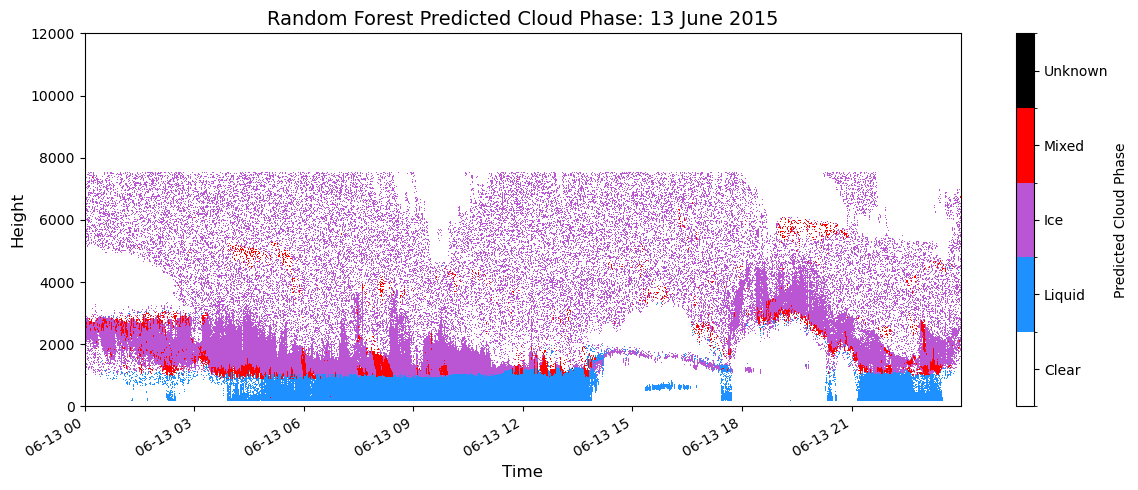

In [90]:
# ============================================================
# Plot observed and predicted phase curtains
# ============================================================

from matplotlib.colors import ListedColormap, BoundaryNorm

phase_label_names = {
    0: "Clear",
    1: "Liquid",
    2: "Ice",
    3: "Mixed",
    4: "Unknown"
}

class_values = sorted(phase_label_names.keys())
class_names = [phase_label_names[i] for i in class_values]

phase_colors = [
    "white",         # Clear
    "dodgerblue",    # Liquid
    "mediumorchid",  # Mixed
    "red",     # Ice
    "black"          # Unknown
]

cmap = ListedColormap(phase_colors)
bounds = np.arange(-0.5, len(class_values) + 0.5, 1)
norm = BoundaryNorm(bounds, cmap.N)

# Observed grid from df_all so the observed curtain is not limited to model-valid points
plot_true_df = df_all.dropna(subset=[label_col]).copy()
plot_true_df["time"] = pd.to_datetime(plot_true_df["time"])
plot_true_df[label_col] = plot_true_df[label_col].astype(int)

true_grid = plot_true_df.pivot_table(
    index="height",
    columns="time",
    values=label_col,
    aggfunc="first"
)

true_grid = true_grid.sort_index().sort_index(axis=1)

# Predicted grid from model_df
plot_pred_df = model_df.copy()
plot_pred_df["time"] = pd.to_datetime(plot_pred_df["time"])
plot_pred_df["phase_pred"] = plot_pred_df["phase_pred"].astype(int)

pred_grid = plot_pred_df.pivot_table(
    index="height",
    columns="time",
    values="phase_pred",
    aggfunc="first"
)

pred_grid = pred_grid.sort_index().sort_index(axis=1)

# ------------------------------------------------------------
# Observed curtain
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 5))

im = ax.pcolormesh(
    true_grid.columns,
    true_grid.index.values,
    true_grid.values,
    shading="auto",
    cmap=cmap,
    norm=norm
)

cbar = fig.colorbar(
    im,
    ax=ax,
    ticks=class_values,
    boundaries=bounds,
    spacing="uniform"
)
cbar.ax.set_yticklabels(class_names)
cbar.set_label("Observed Cloud Phase")

ax.set_title("Observed Cloud Phase: 13 June 2015", fontsize=14)
ax.set_xlabel("Time", fontsize=12)
ax.set_ylabel("Height", fontsize=12)
ax.set_ylim(0, 12000)

fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(f"observed_phase_curtain_{NEW_DATE}.png", dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# Predicted curtain
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 5))

im = ax.pcolormesh(
    pred_grid.columns,
    pred_grid.index.values,
    pred_grid.values,
    shading="auto",
    cmap=cmap,
    norm=norm
)

cbar = fig.colorbar(
    im,
    ax=ax,
    ticks=class_values,
    boundaries=bounds,
    spacing="uniform"
)
cbar.ax.set_yticklabels(class_names)
cbar.set_label("Predicted Cloud Phase")

ax.set_title("Random Forest Predicted Cloud Phase: 13 June 2015", fontsize=14)
ax.set_xlabel("Time", fontsize=12)
ax.set_ylabel("Height", fontsize=12)
ax.set_ylim(0, 12000)

fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(f"predicted_phase_curtain_{NEW_DATE}.png", dpi=300, bbox_inches="tight")
plt.show()

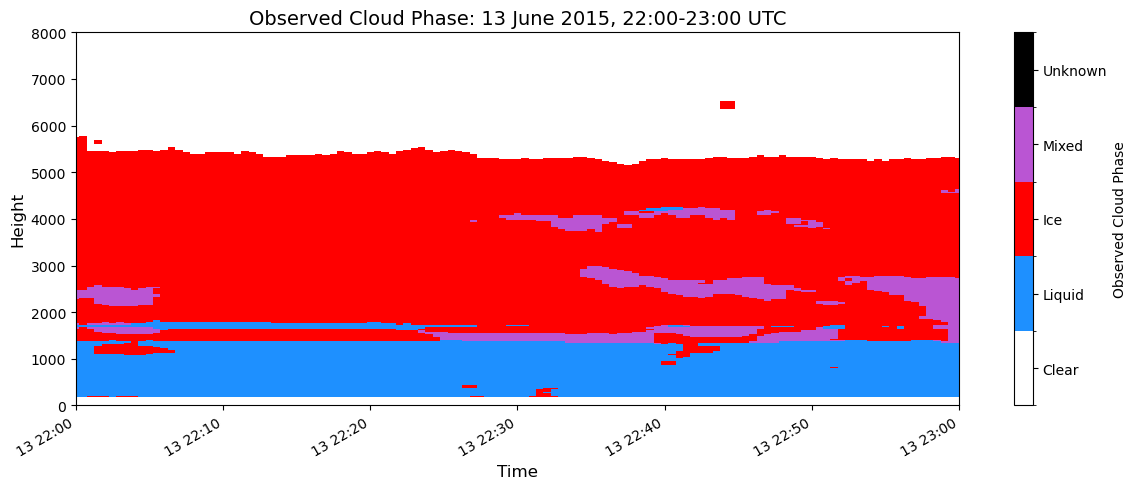

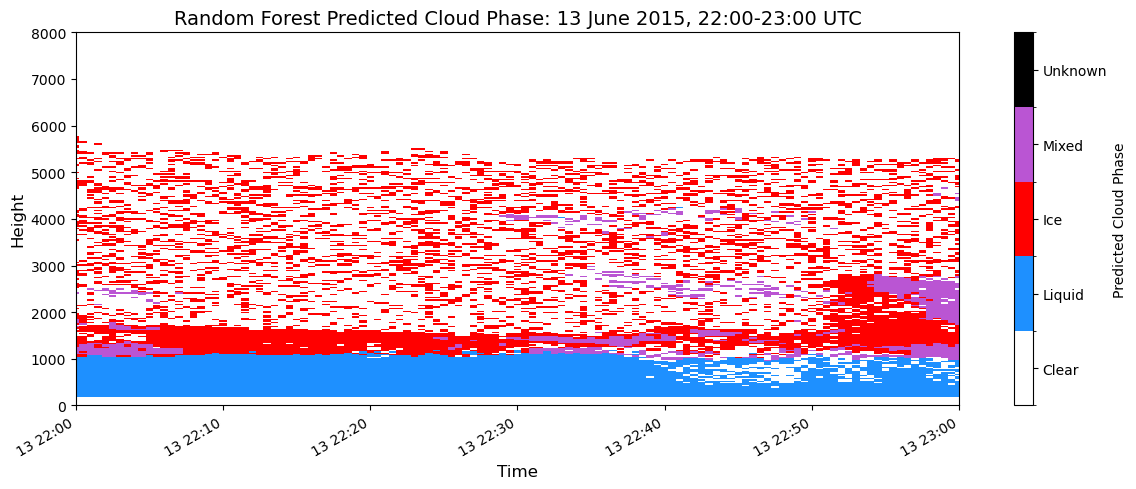

In [97]:
# ============================================================
# Plot observed and predicted phase curtains
# Subset time: 22:00 to 23:00
# ============================================================

from matplotlib.colors import ListedColormap, BoundaryNorm

phase_label_names = {
    0: "Clear",
    1: "Liquid",
    2: "Ice",
    3: "Mixed",
    4: "Unknown"
}

class_values = sorted(phase_label_names.keys())
class_names = [phase_label_names[i] for i in class_values]

phase_colors = [
    "white",         # Clear
    "dodgerblue",    # Liquid
    "red",           # Ice
    "mediumorchid",  # Mixed
    "black"          # Unknown
]

cmap = ListedColormap(phase_colors)
bounds = np.arange(-0.5, len(class_values) + 0.5, 1)
norm = BoundaryNorm(bounds, cmap.N)

# ------------------------------------------------------------
# Time subset
# ------------------------------------------------------------

start_time = pd.Timestamp("2015-06-13 22:00:00")
end_time = pd.Timestamp("2015-06-13 23:00:00")

# Observed grid from df_all so the observed curtain is not limited to model-valid points
plot_true_df = df_all.dropna(subset=[label_col]).copy()
plot_true_df["time"] = pd.to_datetime(plot_true_df["time"])

plot_true_df = plot_true_df[
    (plot_true_df["time"] >= start_time) &
    (plot_true_df["time"] <= end_time)
].copy()

plot_true_df[label_col] = plot_true_df[label_col].astype(int)

true_grid = plot_true_df.pivot_table(
    index="height",
    columns="time",
    values=label_col,
    aggfunc="first"
)

true_grid = true_grid.sort_index().sort_index(axis=1)

# Predicted grid from model_df
plot_pred_df = model_df.copy()
plot_pred_df["time"] = pd.to_datetime(plot_pred_df["time"])

plot_pred_df = plot_pred_df[
    (plot_pred_df["time"] >= start_time) &
    (plot_pred_df["time"] <= end_time)
].copy()

plot_pred_df["phase_pred"] = plot_pred_df["phase_pred"].astype(int)

pred_grid = plot_pred_df.pivot_table(
    index="height",
    columns="time",
    values="phase_pred",
    aggfunc="first"
)

pred_grid = pred_grid.sort_index().sort_index(axis=1)

# ------------------------------------------------------------
# Observed curtain
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 5))

im = ax.pcolormesh(
    true_grid.columns,
    true_grid.index.values,
    true_grid.values,
    shading="auto",
    cmap=cmap,
    norm=norm
)

cbar = fig.colorbar(
    im,
    ax=ax,
    ticks=class_values,
    boundaries=bounds,
    spacing="uniform"
)
cbar.ax.set_yticklabels(class_names)
cbar.set_label("Observed Cloud Phase")

ax.set_title("Observed Cloud Phase: 13 June 2015, 22:00-23:00 UTC", fontsize=14)
ax.set_xlabel("Time", fontsize=12)
ax.set_ylabel("Height", fontsize=12)
ax.set_ylim(0, 8000)
ax.set_xlim(start_time, end_time)

fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(f"observed_phase_curtain_{NEW_DATE}_2200_2300.png", dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# Predicted curtain
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 5))

im = ax.pcolormesh(
    pred_grid.columns,
    pred_grid.index.values,
    pred_grid.values,
    shading="auto",
    cmap=cmap,
    norm=norm
)

cbar = fig.colorbar(
    im,
    ax=ax,
    ticks=class_values,
    boundaries=bounds,
    spacing="uniform"
)
cbar.ax.set_yticklabels(class_names)
cbar.set_label("Predicted Cloud Phase")

ax.set_title("Random Forest Predicted Cloud Phase: 13 June 2015, 22:00-23:00 UTC", fontsize=14)
ax.set_xlabel("Time", fontsize=12)
ax.set_ylabel("Height", fontsize=12)
ax.set_ylim(0, 8000)
ax.set_xlim(start_time, end_time)

fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(f"predicted_phase_curtain_{NEW_DATE}_2200_2300.png", dpi=300, bbox_inches="tight")
plt.show()

In [98]:
#Imports for aircraft data
#Imports
import os
from pathlib import Path
import glob
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd
import cartopy.crs as ccrs

import getpass
import act
from act.io.icartt import read_icartt

In [99]:
#Import AAFMERGED Dataset
# Check for env variables, otherwise set your username and token here!
if "ARM_USERNAME" in os.environ:
    arm_username = os.getenv("ARM_USERNAME")
else:
    arm_username = input("Enter ARM username: ").strip()
if "ARM_TOKEN" in os.environ:
    arm_token = os.getenv("ARM_TOKEN")
else:
    arm_token = getpass.getpass("Enter ARM token (hidden): ").strip()

# Set the datastream and start/enddates
aaf_datastream = 'nsaaafmergedF1.c1'

#token: 45849aad075e952d

startdate = '2015-05-21'
enddate = '2015-09-15'

startdate_single = '2015-06-13'
enddate_single = '2015-06-14'

result_aaf_met = act.discovery.download_arm_data(arm_username, arm_token, aaf_datastream, startdate, enddate)
single_aaf_met = act.discovery.download_arm_data(arm_username, arm_token, aaf_datastream, startdate_single, enddate_single)

Enter ARM username:  cnairy
Enter ARM token (hidden):  ········


[DOWNLOADING] nsaaafmergedF1.c1.20150521.170720.nc
[DOWNLOADING] nsaaafmergedF1.c1.20150604.223121.nc
[DOWNLOADING] nsaaafmergedF1.c1.20150607.200851.nc
[DOWNLOADING] nsaaafmergedF1.c1.20150608.195637.nc
[DOWNLOADING] nsaaafmergedF1.c1.20150610.183918.nc
[DOWNLOADING] nsaaafmergedF1.c1.20150612.215820.nc
[DOWNLOADING] nsaaafmergedF1.c1.20150613.185718.nc
[DOWNLOADING] nsaaafmergedF1.c1.20150615.215726.nc
[DOWNLOADING] nsaaafmergedF1.c1.20150617.185936.nc
[DOWNLOADING] nsaaafmergedF1.c1.20150620.190037.nc
[DOWNLOADING] nsaaafmergedF1.c1.20150622.231743.nc
[DOWNLOADING] nsaaafmergedF1.c1.20150623.191417.nc
[DOWNLOADING] nsaaafmergedF1.c1.20150627.210618.nc
[DOWNLOADING] nsaaafmergedF1.c1.20150630.185946.nc
[DOWNLOADING] nsaaafmergedF1.c1.20150702.193403.nc
[DOWNLOADING] nsaaafmergedF1.c1.20150705.185714.nc
[DOWNLOADING] nsaaafmergedF1.c1.20150711.202714.nc
[DOWNLOADING] nsaaafmergedF1.c1.20150714.190115.nc
[DOWNLOADING] nsaaafmergedF1.c1.20150716.195843.nc
[DOWNLOADING] nsaaafmergedF1.c1

In [100]:
# See if we can plot one of the AAFMERGED data attributes (2DS number concentrations)
ds_cf_met = act.io.read_arm_netcdf(single_aaf_met)
ds_cf_met = ds_cf_met.sel(time=slice('2015-06-13T22:10', '2015-06-13T22:45'))

Aircraft points after latitude filter: 2115
PNG files found: 819
Usable 2DS image files after filename parsing: 409
Matched 112 images to aircraft positions.
Match tolerance: 30 seconds


,image_time,time,filename,lon,lat,press_alt
0,2015-06-13 22:10:13,2015-06-13 22:10:13,2DS_H_ACMEV_G1_images.20150613a_221013_162142_...,-156.900177,71.038170,21.945601
1,2015-06-13 22:11:16,2015-06-13 22:11:16,2DS_H_ACMEV_G1_images.20150613a_221116_938978_...,-156.831177,71.087502,32.004002
2,2015-06-13 22:11:36,2015-06-13 22:11:36,2DS_H_ACMEV_G1_images.20150613a_221136_375878_...,-156.809174,71.103172,35.356800
3,2015-06-13 22:11:58,2015-06-13 22:11:58,2DS_H_ACMEV_G1_images.20150613a_221158_034566_...,-156.784332,71.120171,38.709599
4,2015-06-13 22:12:27,2015-06-13 22:12:27,2DS_H_ACMEV_G1_images.20150613a_221227_062186_...,-156.752502,71.142670,39.624001


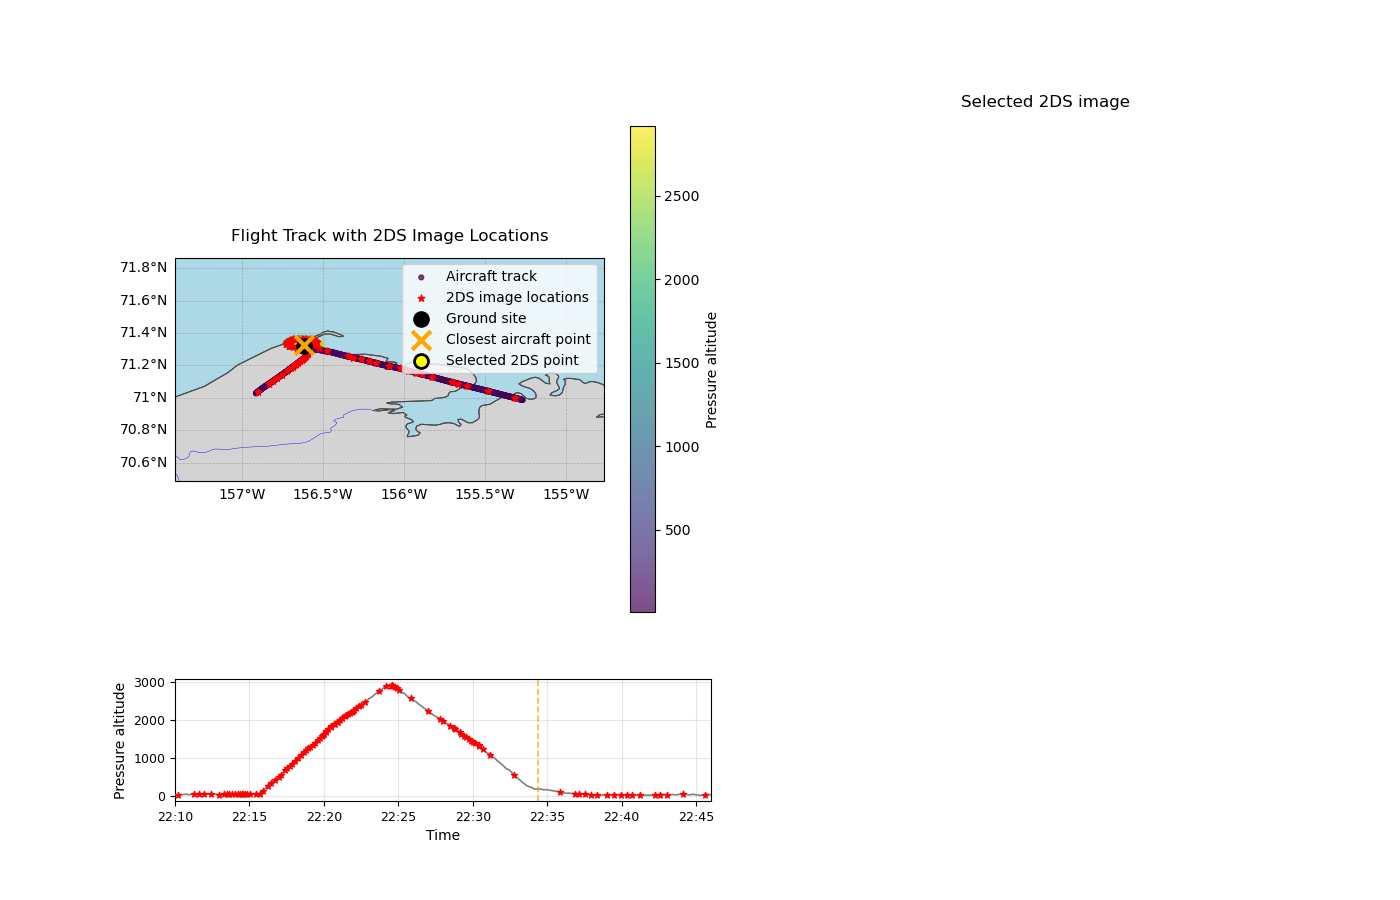


Closest aircraft point to ground site:
Time:      2015-06-13 22:34:21
Longitude: -156.6162
Latitude:  71.3237
Pressure altitude: 179.2
Distance:  0.09 km

Matplotlib backend being used:
module://ipympl.backend_nbagg


In [101]:
%matplotlib widget

import os
import glob
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib
import matplotlib.dates as mdates
import ipywidgets as widgets
from IPython.display import display

import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Close old figures
plt.close("all")

# ============================================================
# User settings
# ============================================================

image_dir = "/data/home/cnairy/2DS_Images_H/"

site_lon = -156.615
site_lat = 71.323

min_lat = 40

# Increase if images are sparse
match_tolerance_seconds = 30

# Starting map behavior
zoom_to_site = False
zoom_lon_buffer = 0.08
zoom_lat_buffer = 0.04

# Full-flight map buffer when zoom_to_site = False
map_lon_buffer = 0.5
map_lat_buffer = 0.5

# Auto-zoom map when selected 2DS point is near the ground site
auto_zoom_within_site_km = 3.5

# Zoom extent when selected point is within 1 km of site
site_zoom_lon_buffer = 0.03
site_zoom_lat_buffer = 0.02

# ============================================================
# Filter aircraft data
# ============================================================

mask = (ds_cf_met.lat >= min_lat).compute()

lon = ds_cf_met.lon.where(mask, drop=True)
lat = ds_cf_met.lat.where(mask, drop=True)
press_alt = ds_cf_met.press_alt.where(mask, drop=True)
time = ds_cf_met.time.where(mask, drop=True)

aircraft_df = pd.DataFrame({
    "time": pd.to_datetime(time.values),
    "lon": lon.values,
    "lat": lat.values,
    "press_alt": press_alt.values
})

aircraft_df = aircraft_df.dropna(subset=["time", "lon", "lat", "press_alt"])
aircraft_df = aircraft_df.sort_values("time").reset_index(drop=True)

print(f"Aircraft points after latitude filter: {len(aircraft_df)}")

# ============================================================
# Read 2DS image filenames
# ============================================================

image_files = sorted(
    glob.glob(os.path.join(image_dir, "*.png")) +
    glob.glob(os.path.join(image_dir, "*.PNG"))
)

records = []

# Example:
# 2DS_H_ACMEV_G1_images.20150613a_223109_950890_RA.png
pattern = re.compile(r".*?(\d{8})[a-zA-Z]?_(\d{6})_.*\.(png|PNG)$")

for f in image_files:
    fname = os.path.basename(f)
    match = pattern.match(fname)

    if match is None:
        continue

    date_str = match.group(1)
    time_str = match.group(2)

    image_time = pd.to_datetime(
        date_str + time_str,
        format="%Y%m%d%H%M%S"
    )

    records.append({
        "image_time": image_time,
        "image_path": f,
        "filename": fname
    })

image_df = pd.DataFrame(records)

print(f"PNG files found: {len(image_files)}")
print(f"Usable 2DS image files after filename parsing: {len(image_df)}")

if len(image_df) == 0:
    raise ValueError(
        "No usable 2DS images found. Check image_dir and filename pattern."
    )

image_df = image_df.sort_values("image_time").reset_index(drop=True)

# ============================================================
# Match image times to aircraft times
# ============================================================

matched_df = pd.merge_asof(
    image_df,
    aircraft_df,
    left_on="image_time",
    right_on="time",
    direction="nearest",
    tolerance=pd.Timedelta(seconds=match_tolerance_seconds)
)

matched_df = matched_df.dropna(subset=["lon", "lat", "press_alt"]).reset_index(drop=True)

print(f"Matched {len(matched_df)} images to aircraft positions.")
print(f"Match tolerance: {match_tolerance_seconds} seconds")

if len(matched_df) == 0:
    raise ValueError(
        "No images matched to aircraft data. Try increasing "
        "match_tolerance_seconds to 60, 120, or 300."
    )

display(
    matched_df[
        ["image_time", "time", "filename", "lon", "lat", "press_alt"]
    ].head()
)

# ============================================================
# Distance to ground site
# ============================================================

def haversine(lon1, lat1, lon2, lat2):
    R = 6371.0

    lon1 = np.deg2rad(lon1)
    lat1 = np.deg2rad(lat1)
    lon2 = np.deg2rad(lon2)
    lat2 = np.deg2rad(lat2)

    dlon = lon1 - lon2
    dlat = lat1 - lat2

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat2) * np.cos(lat1) * np.sin(dlon / 2) ** 2
    )

    c = 2 * np.arcsin(np.sqrt(a))

    return R * c

aircraft_df["distance_to_site_km"] = haversine(
    aircraft_df["lon"].values,
    aircraft_df["lat"].values,
    site_lon,
    site_lat
)

matched_df["distance_to_site_km"] = haversine(
    matched_df["lon"].values,
    matched_df["lat"].values,
    site_lon,
    site_lat
)

closest_idx = int(aircraft_df["distance_to_site_km"].idxmin())
closest_row = aircraft_df.loc[closest_idx]
closest_dist = closest_row["distance_to_site_km"]

# Sort matched images by time
matched_df = matched_df.sort_values("image_time").reset_index(drop=True)

# Start near the image closest to the ground site
start_idx = int(matched_df["distance_to_site_km"].idxmin())

# ============================================================
# Create matplotlib figure
# ============================================================

fig = plt.figure(figsize=(14, 9))

gs = fig.add_gridspec(
    nrows=2,
    ncols=2,
    width_ratios=[1.25, 1],
    height_ratios=[4, 1],
    wspace=0.25,
    hspace=0.22
)

# Cartopy map axis
ax_map = fig.add_subplot(gs[0, 0], projection=ccrs.PlateCarree())

# Regular axes
ax_alt = fig.add_subplot(gs[1, 0])
ax_img = fig.add_subplot(gs[:, 1])

# ============================================================
# Map helper functions
# ============================================================

def set_full_map_extent():
    ax_map.set_extent(
        [
            aircraft_df["lon"].min() - map_lon_buffer,
            aircraft_df["lon"].max() + map_lon_buffer,
            aircraft_df["lat"].min() - map_lat_buffer,
            aircraft_df["lat"].max() + map_lat_buffer,
        ],
        crs=ccrs.PlateCarree()
    )

def set_site_zoom_extent():
    ax_map.set_extent(
        [
            site_lon - site_zoom_lon_buffer,
            site_lon + site_zoom_lon_buffer,
            site_lat - site_zoom_lat_buffer,
            site_lat + site_zoom_lat_buffer,
        ],
        crs=ccrs.PlateCarree()
    )

def set_initial_map_extent():
    if zoom_to_site:
        ax_map.set_extent(
            [
                site_lon - zoom_lon_buffer,
                site_lon + zoom_lon_buffer,
                site_lat - zoom_lat_buffer,
                site_lat + zoom_lat_buffer,
            ],
            crs=ccrs.PlateCarree()
        )
    else:
        set_full_map_extent()

def set_map_extent_for_selected_point(row):
    if row["distance_to_site_km"] <= auto_zoom_within_site_km:
        set_site_zoom_extent()
    else:
        set_full_map_extent()

# ============================================================
# Map: latitude/longitude aircraft track with land/water
# ============================================================

# Add map background features
ax_map.add_feature(cfeature.OCEAN, facecolor="lightblue", zorder=0)
ax_map.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)
ax_map.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=1)
ax_map.add_feature(cfeature.BORDERS, linewidth=0.5, zorder=1)
ax_map.add_feature(
    cfeature.LAKES,
    facecolor="lightblue",
    edgecolor="black",
    linewidth=0.3,
    zorder=1
)
ax_map.add_feature(cfeature.RIVERS, edgecolor="blue", linewidth=0.3, zorder=1)
ax_map.add_feature(cfeature.STATES, linewidth=0.4, edgecolor="gray", zorder=1)

# Set initial map extent
set_initial_map_extent()

# Aircraft track colored by pressure altitude
sc_track = ax_map.scatter(
    aircraft_df["lon"],
    aircraft_df["lat"],
    c=aircraft_df["press_alt"],
    cmap="viridis",
    s=12,
    alpha=0.7,
    label="Aircraft track",
    transform=ccrs.PlateCarree(),
    zorder=3
)

# 2DS image locations
ax_map.scatter(
    matched_df["lon"],
    matched_df["lat"],
    color="red",
    marker="*",
    s=25,
    label="2DS image locations",
    transform=ccrs.PlateCarree(),
    zorder=5
)

# Ground site
ax_map.scatter(
    site_lon,
    site_lat,
    color="black",
    s=120,
    label="Ground site",
    transform=ccrs.PlateCarree(),
    zorder=6
)

# Closest aircraft point to ground site
ax_map.scatter(
    closest_row["lon"],
    closest_row["lat"],
    color="orange",
    s=180,
    marker="x",
    linewidths=3,
    label="Closest aircraft point",
    transform=ccrs.PlateCarree(),
    zorder=7
)

# Selected point marker
selected_marker = ax_map.scatter(
    [],
    [],
    color="yellow",
    s=100,
    marker="o",
    edgecolors="black",
    linewidths=2,
    transform=ccrs.PlateCarree(),
    zorder=10,
    label="Selected 2DS point"
)

# Gridlines
gl = ax_map.gridlines(
    draw_labels=True,
    linewidth=0.5,
    color="gray",
    alpha=0.5,
    linestyle="--"
)

gl.top_labels = False
gl.right_labels = False

ax_map.set_title("Flight Track with 2DS Image Locations", pad=12)

cbar = fig.colorbar(sc_track, ax=ax_map)
cbar.set_label("Pressure altitude")

ax_map.legend(loc="best")

# ============================================================
# Skinny time-pressure altitude plot
# ============================================================

ax_alt.plot(
    aircraft_df["time"],
    aircraft_df["press_alt"],
    color="gray",
    linewidth=1.2,
    label="Aircraft pressure altitude"
)

ax_alt.scatter(
    matched_df["time"],
    matched_df["press_alt"],
    color="red",
    marker="*",
    s=20,
    zorder=5,
    label="2DS image times"
)

selected_alt_marker = ax_alt.scatter(
    [],
    [],
    color="yellow",
    s=90,
    marker="o",
    edgecolors="black",
    linewidths=1.5,
    zorder=10,
    label="Selected 2DS image"
)

# Mark the aircraft time closest to the site
ax_alt.axvline(
    closest_row["time"],
    color="orange",
    linestyle="--",
    linewidth=1.2,
    alpha=0.8,
    label="Closest site overpass"
)

ax_alt.set_ylabel("Pressure altitude")
ax_alt.set_xlabel("Time")
ax_alt.grid(True, alpha=0.3)

ax_alt.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax_alt.tick_params(axis="both", labelsize=9)

# Keep x-axis tight to flight time
ax_alt.set_xlim(aircraft_df["time"].min(), aircraft_df["time"].max())

# ============================================================
# Image panel
# ============================================================

ax_img.set_title("Selected 2DS image", pad=14)
ax_img.axis("off")

# Extra top buffer so titles are not cut off
fig.subplots_adjust(top=0.86)

plt.show()

# ============================================================
# Widgets
# ============================================================

idx_slider = widgets.IntSlider(
    value=start_idx,
    min=0,
    max=len(matched_df) - 1,
    step=1,
    description="Image index:",
    continuous_update=False,
    layout=widgets.Layout(width="700px")
)

prev_button = widgets.Button(
    description="Previous",
    button_style=""
)

next_button = widgets.Button(
    description="Next",
    button_style=""
)

jump_site_button = widgets.Button(
    description="Closest to site",
    button_style="info"
)

full_map_button = widgets.Button(
    description="Full map",
    button_style=""
)

site_zoom_button = widgets.Button(
    description="Zoom site",
    button_style=""
)

info_box = widgets.HTML()

options = [
    (
        f"{i}: {row.image_time} | {row.distance_to_site_km:.2f} km | {row.filename}",
        i
    )
    for i, row in matched_df.iterrows()
]

dropdown = widgets.Dropdown(
    options=options,
    value=start_idx,
    description="Select:",
    layout=widgets.Layout(width="900px")
)

# ============================================================
# Update function
# ============================================================

def update_display(idx):
    idx = int(idx)

    row = matched_df.iloc[idx]
    image_path = row["image_path"]

    if not os.path.exists(image_path):
        info_box.value = f"<b>Image file not found:</b> {image_path}"
        return

    try:
        img = mpimg.imread(image_path)
    except Exception as e:
        info_box.value = f"<b>Could not read image:</b> {e}"
        return

    # Update selected marker on map
    selected_marker.set_offsets([[row["lon"], row["lat"]]])

    # Auto-zoom x-y map if selected 2DS point is within 1 km of site
    set_map_extent_for_selected_point(row)

    # Update selected marker on time-pressure altitude plot
    selected_alt_marker.set_offsets([
        [mdates.date2num(row["time"]), row["press_alt"]]
    ])

    # Update image panel
    ax_img.clear()
    ax_img.imshow(img, cmap="gray")
    ax_img.axis("off")

    ax_img.set_title(
        f"{row['filename']}\n"
        f"Image time: {row['image_time']}\n"
        f"Aircraft time: {row['time']}\n"
        f"Distance to site: {row['distance_to_site_km']:.2f} km\n"
        f"Pressure altitude: {row['press_alt']:.1f}",
        fontsize=10,
        pad=14
    )

    zoom_status = (
        "Map auto-zoomed to site"
        if row["distance_to_site_km"] <= auto_zoom_within_site_km
        else "Map showing full flight"
    )

    info_box.value = (
        f"<b>Selected image:</b> {idx + 1} of {len(matched_df)}<br>"
        f"<b>Filename:</b> {row['filename']}<br>"
        f"<b>Image time:</b> {row['image_time']}<br>"
        f"<b>Aircraft time:</b> {row['time']}<br>"
        f"<b>Longitude:</b> {row['lon']:.4f}<br>"
        f"<b>Latitude:</b> {row['lat']:.4f}<br>"
        f"<b>Pressure altitude:</b> {row['press_alt']:.1f}<br>"
        f"<b>Distance to site:</b> {row['distance_to_site_km']:.2f} km<br>"
        f"<b>Map status:</b> {zoom_status}"
    )

    fig.canvas.draw_idle()

# ============================================================
# Widget callbacks
# ============================================================

def on_slider_change(change):
    if change["name"] == "value":
        dropdown.value = change["new"]
        update_display(change["new"])

def on_dropdown_change(change):
    if change["name"] == "value":
        idx_slider.value = change["new"]
        update_display(change["new"])

def on_prev_clicked(button):
    idx_slider.value = max(idx_slider.min, idx_slider.value - 1)

def on_next_clicked(button):
    idx_slider.value = min(idx_slider.max, idx_slider.value + 1)

def on_jump_site_clicked(button):
    idx_slider.value = start_idx

def on_full_map_clicked(button):
    set_full_map_extent()
    fig.canvas.draw_idle()

def on_site_zoom_clicked(button):
    set_site_zoom_extent()
    fig.canvas.draw_idle()

idx_slider.observe(on_slider_change, names="value")
dropdown.observe(on_dropdown_change, names="value")
prev_button.on_click(on_prev_clicked)
next_button.on_click(on_next_clicked)
jump_site_button.on_click(on_jump_site_clicked)
full_map_button.on_click(on_full_map_clicked)
site_zoom_button.on_click(on_site_zoom_clicked)

controls = widgets.VBox([
    widgets.HBox([
        prev_button,
        next_button,
        jump_site_button,
        full_map_button,
        site_zoom_button
    ]),
    idx_slider,
    dropdown,
    info_box
])

display(controls)

# Show first selected image
update_display(start_idx)

# ============================================================
# Print closest aircraft point to ground site
# ============================================================

print("\nClosest aircraft point to ground site:")
print(f"Time:      {closest_row['time']}")
print(f"Longitude: {closest_row['lon']:.4f}")
print(f"Latitude:  {closest_row['lat']:.4f}")
print(f"Pressure altitude: {closest_row['press_alt']:.1f}")
print(f"Distance:  {closest_dist:.2f} km")

print("\nMatplotlib backend being used:")
print(matplotlib.get_backend())

Three closest 2DS image points:


,image_time,time,filename,lon,lat,press_alt,distance_to_site_km
0,2015-06-13 22:16:13,2015-06-13 22:16:13,2DS_H_ACMEV_G1_images.20150613a_221613_279601_...,-156.614670,71.326828,250.545593,0.425470
1,2015-06-13 22:15:55,2015-06-13 22:15:55,2DS_H_ACMEV_G1_images.20150613a_221555_263727_...,-156.606674,71.311668,132.892807,1.294356
2,2015-06-13 22:19:46,2015-06-13 22:19:46,2DS_H_ACMEV_G1_images.20150613a_221946_405491_...,-156.600327,71.312332,1528.572021,1.296304


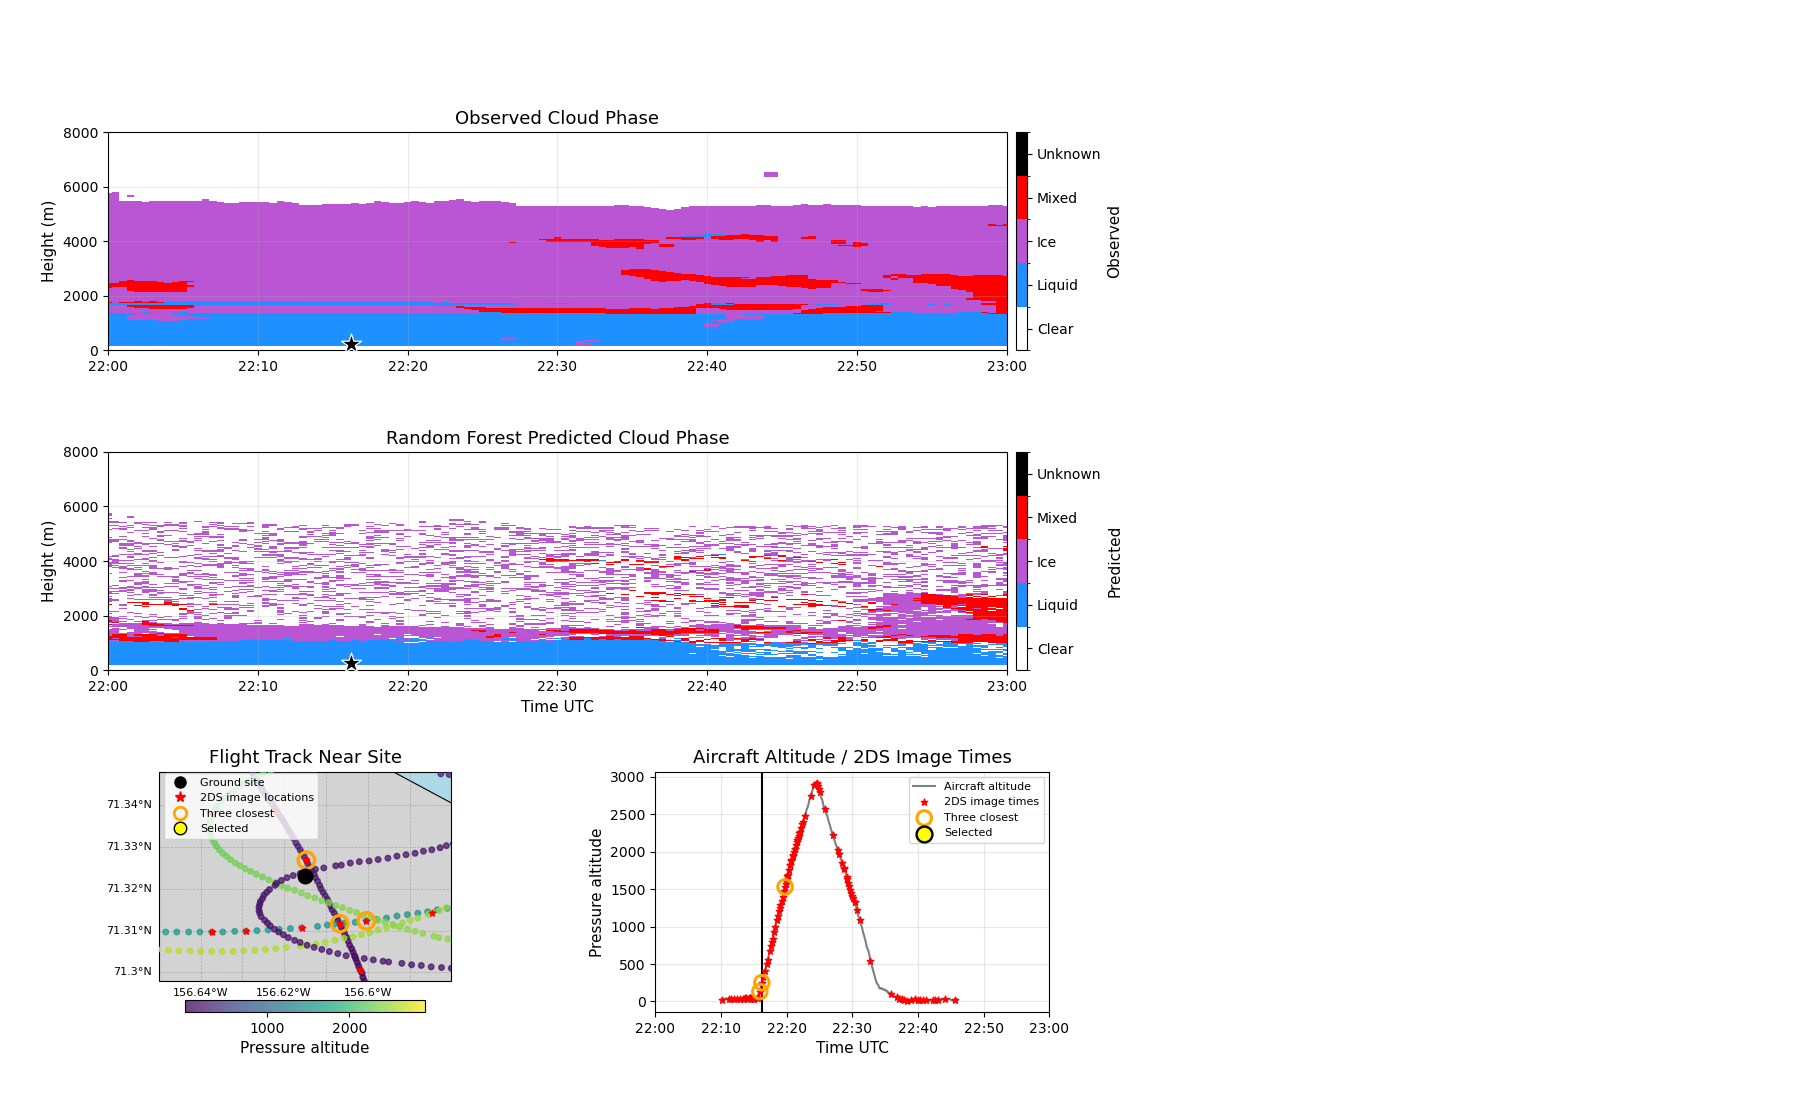

In [104]:
# ============================================================
# Interactive combined cloud phase curtains + three closest 2DS images
# Cleaner organized layout with black stars on phase curtains
# ============================================================

%matplotlib widget

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.dates as mdates
import ipywidgets as widgets

from matplotlib.colors import ListedColormap, BoundaryNorm
from IPython.display import display

import cartopy.crs as ccrs
import cartopy.feature as cfeature

plt.close("all")

# ============================================================
# Settings
# ============================================================

start_time = pd.Timestamp("2015-06-13 22:00:00")
end_time = pd.Timestamp("2015-06-13 23:00:00")

n_closest = 3

height_ylim = (0, 8000)

site_zoom_lon_buffer = 0.035
site_zoom_lat_buffer = 0.025

plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9
})

# ============================================================
# Cloud phase color settings
# ============================================================

phase_label_names = {
    0: "Clear",
    1: "Liquid",
    2: "Ice",
    3: "Mixed",
    4: "Unknown"
}

class_values = sorted(phase_label_names.keys())
class_names = [phase_label_names[i] for i in class_values]

phase_colors = [
    "white",         # Clear
    "dodgerblue",   # Liquid
    "mediumorchid",          # Ice
    "red", # Mixed
    "black"         # Unknown
]

cmap = ListedColormap(phase_colors)
bounds = np.arange(-0.5, len(class_values) + 0.5, 1)
norm = BoundaryNorm(bounds, cmap.N)

# ============================================================
# Prepare observed phase grid
# ============================================================

plot_true_df = df_all.dropna(subset=[label_col]).copy()
plot_true_df["time"] = pd.to_datetime(plot_true_df["time"])

plot_true_df = plot_true_df[
    (plot_true_df["time"] >= start_time) &
    (plot_true_df["time"] <= end_time)
].copy()

plot_true_df[label_col] = plot_true_df[label_col].astype(int)

true_grid = plot_true_df.pivot_table(
    index="height",
    columns="time",
    values=label_col,
    aggfunc="first"
)

true_grid = true_grid.sort_index().sort_index(axis=1)

# ============================================================
# Prepare predicted phase grid
# ============================================================

plot_pred_df = model_df.copy()
plot_pred_df["time"] = pd.to_datetime(plot_pred_df["time"])

plot_pred_df = plot_pred_df[
    (plot_pred_df["time"] >= start_time) &
    (plot_pred_df["time"] <= end_time)
].copy()

plot_pred_df["phase_pred"] = plot_pred_df["phase_pred"].astype(int)

pred_grid = plot_pred_df.pivot_table(
    index="height",
    columns="time",
    values="phase_pred",
    aggfunc="first"
)

pred_grid = pred_grid.sort_index().sort_index(axis=1)

# ============================================================
# Select three closest 2DS image points to the field site
# ============================================================

matched_df["image_time"] = pd.to_datetime(matched_df["image_time"])
matched_df["time"] = pd.to_datetime(matched_df["time"])
aircraft_df["time"] = pd.to_datetime(aircraft_df["time"])

closest_2ds_df = (
    matched_df
    .dropna(subset=[
        "image_time",
        "time",
        "image_path",
        "lon",
        "lat",
        "press_alt",
        "distance_to_site_km"
    ])
    .sort_values("distance_to_site_km")
    .head(n_closest)
    .reset_index(drop=True)
)

if len(closest_2ds_df) == 0:
    raise ValueError("No valid 2DS images found near the field site.")

print("Three closest 2DS image points:")
display(
    closest_2ds_df[
        ["image_time", "time", "filename", "lon", "lat", "press_alt", "distance_to_site_km"]
    ]
)

# ============================================================
# Create organized figure layout
# ============================================================

fig = plt.figure(figsize=(18, 11))

gs = fig.add_gridspec(
    nrows=3,
    ncols=3,
    width_ratios=[1.35, 1.35, 1.8],
    height_ratios=[1.0, 1.0, 1.1],
    wspace=0.35,
    hspace=0.45
)

ax_obs = fig.add_subplot(gs[0, 0:2])
ax_pred = fig.add_subplot(gs[1, 0:2])
ax_map = fig.add_subplot(gs[2, 0], projection=ccrs.PlateCarree())
ax_alt = fig.add_subplot(gs[2, 1])
ax_img = fig.add_subplot(gs[:, 2])

# ============================================================
# Observed cloud phase curtain
# ============================================================

im_obs = ax_obs.pcolormesh(
    true_grid.columns,
    true_grid.index.values,
    true_grid.values,
    shading="auto",
    cmap=cmap,
    norm=norm
)

obs_star = ax_obs.scatter(
    closest_2ds_df.loc[0, "image_time"],
    closest_2ds_df.loc[0, "press_alt"],
    marker="*",
    s=230,
    color="black",
    edgecolors="white",
    linewidths=0.9,
    zorder=20
)

ax_obs.set_title("Observed Cloud Phase")
ax_obs.set_ylabel("Height (m)")
ax_obs.set_ylim(height_ylim)
ax_obs.set_xlim(start_time, end_time)
ax_obs.grid(True, alpha=0.25)
ax_obs.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

cbar_obs = fig.colorbar(
    im_obs,
    ax=ax_obs,
    ticks=class_values,
    boundaries=bounds,
    spacing="uniform",
    pad=0.01,
    fraction=0.035
)

cbar_obs.ax.set_yticklabels(class_names)
cbar_obs.set_label("Observed")

# ============================================================
# Predicted cloud phase curtain
# ============================================================

im_pred = ax_pred.pcolormesh(
    pred_grid.columns,
    pred_grid.index.values,
    pred_grid.values,
    shading="auto",
    cmap=cmap,
    norm=norm
)

pred_star = ax_pred.scatter(
    closest_2ds_df.loc[0, "image_time"],
    closest_2ds_df.loc[0, "press_alt"],
    marker="*",
    s=230,
    color="black",
    edgecolors="white",
    linewidths=0.9,
    zorder=20
)

ax_pred.set_title("Random Forest Predicted Cloud Phase")
ax_pred.set_xlabel("Time UTC")
ax_pred.set_ylabel("Height (m)")
ax_pred.set_ylim(height_ylim)
ax_pred.set_xlim(start_time, end_time)
ax_pred.grid(True, alpha=0.25)
ax_pred.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

cbar_pred = fig.colorbar(
    im_pred,
    ax=ax_pred,
    ticks=class_values,
    boundaries=bounds,
    spacing="uniform",
    pad=0.01,
    fraction=0.035
)

cbar_pred.ax.set_yticklabels(class_names)
cbar_pred.set_label("Predicted")

# ============================================================
# Map panel
# ============================================================

ax_map.add_feature(cfeature.OCEAN, facecolor="lightblue", zorder=0)
ax_map.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)
ax_map.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=1)
ax_map.add_feature(cfeature.LAKES, facecolor="lightblue", edgecolor="black", linewidth=0.3, zorder=1)
ax_map.add_feature(cfeature.RIVERS, edgecolor="blue", linewidth=0.3, zorder=1)

ax_map.set_extent(
    [
        site_lon - site_zoom_lon_buffer,
        site_lon + site_zoom_lon_buffer,
        site_lat - site_zoom_lat_buffer,
        site_lat + site_zoom_lat_buffer,
    ],
    crs=ccrs.PlateCarree()
)

sc_track = ax_map.scatter(
    aircraft_df["lon"],
    aircraft_df["lat"],
    c=aircraft_df["press_alt"],
    cmap="viridis",
    s=16,
    alpha=0.75,
    transform=ccrs.PlateCarree(),
    zorder=3
)

ax_map.scatter(
    matched_df["lon"],
    matched_df["lat"],
    color="red",
    marker="*",
    s=22,
    transform=ccrs.PlateCarree(),
    zorder=4
)

ax_map.scatter(
    closest_2ds_df["lon"],
    closest_2ds_df["lat"],
    facecolors="none",
    edgecolors="orange",
    linewidths=2.4,
    s=140,
    transform=ccrs.PlateCarree(),
    zorder=8
)

ax_map.scatter(
    site_lon,
    site_lat,
    color="black",
    s=110,
    transform=ccrs.PlateCarree(),
    zorder=9
)

selected_map_marker = ax_map.scatter(
    [],
    [],
    color="yellow",
    edgecolors="black",
    linewidths=2,
    s=170,
    transform=ccrs.PlateCarree(),
    zorder=10
)

gl = ax_map.gridlines(
    draw_labels=True,
    linewidth=0.5,
    color="gray",
    alpha=0.5,
    linestyle="--"
)

gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {"size": 8}
gl.ylabel_style = {"size": 8}

ax_map.set_title("Flight Track Near Site")

cbar_map = fig.colorbar(
    sc_track,
    ax=ax_map,
    orientation="horizontal",
    pad=0.08,
    fraction=0.05
)

cbar_map.set_label("Pressure altitude")

legend_handles = [
    plt.Line2D(
        [],
        [],
        marker="o",
        color="none",
        markerfacecolor="black",
        markeredgecolor="black",
        markersize=8,
        label="Ground site"
    ),
    plt.Line2D(
        [],
        [],
        marker="*",
        color="red",
        linestyle="None",
        markersize=8,
        label="2DS image locations"
    ),
    plt.Line2D(
        [],
        [],
        marker="o",
        color="orange",
        markerfacecolor="none",
        markeredgewidth=2,
        linestyle="None",
        markersize=9,
        label="Three closest"
    ),
    plt.Line2D(
        [],
        [],
        marker="o",
        color="black",
        markerfacecolor="yellow",
        linestyle="None",
        markersize=9,
        label="Selected"
    )
]

ax_map.legend(
    handles=legend_handles,
    loc="upper left",
    bbox_to_anchor=(0.0, 1.02),
    frameon=True,
    fontsize=8
)

# ============================================================
# Time-altitude panel
# ============================================================

ax_alt.plot(
    aircraft_df["time"],
    aircraft_df["press_alt"],
    color="gray",
    linewidth=1.5,
    label="Aircraft altitude"
)

ax_alt.scatter(
    matched_df["time"],
    matched_df["press_alt"],
    color="red",
    marker="*",
    s=24,
    label="2DS image times",
    zorder=5
)

ax_alt.scatter(
    closest_2ds_df["time"],
    closest_2ds_df["press_alt"],
    facecolors="none",
    edgecolors="orange",
    linewidths=2.2,
    s=110,
    label="Three closest",
    zorder=8
)

selected_alt_marker = ax_alt.scatter(
    [],
    [],
    color="yellow",
    edgecolors="black",
    linewidths=1.7,
    s=130,
    label="Selected",
    zorder=10
)

selected_alt_line = ax_alt.axvline(
    closest_2ds_df.loc[0, "time"],
    color="black",
    linewidth=1.5
)

ax_alt.set_title("Aircraft Altitude / 2DS Image Times")
ax_alt.set_xlim(start_time, end_time)
ax_alt.set_xlabel("Time UTC")
ax_alt.set_ylabel("Pressure altitude")
ax_alt.grid(True, alpha=0.3)
ax_alt.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

ax_alt.legend(
    loc="upper right",
    frameon=True,
    fontsize=8
)

# ============================================================
# 2DS image panel
# ============================================================

ax_img.axis("off")

# ============================================================
# Widgets
# ============================================================

current_idx = widgets.IntText(value=0, layout=widgets.Layout(display="none"))

prev_button = widgets.Button(
    description="Previous",
    layout=widgets.Layout(width="120px")
)

next_button = widgets.Button(
    description="Next",
    layout=widgets.Layout(width="120px")
)

info_box = widgets.HTML()

def update_display(idx):
    idx = int(idx)

    row = closest_2ds_df.iloc[idx]

    image_time = row["image_time"]
    aircraft_time = row["time"]
    image_path = row["image_path"]

    selected_map_marker.set_offsets([[row["lon"], row["lat"]]])

    selected_alt_marker.set_offsets([
        [mdates.date2num(aircraft_time), row["press_alt"]]
    ])

    obs_star.set_offsets([
        [mdates.date2num(image_time), row["press_alt"]]
    ])

    pred_star.set_offsets([
        [mdates.date2num(image_time), row["press_alt"]]
    ])

    selected_alt_line.set_xdata([aircraft_time, aircraft_time])

    ax_img.clear()
    ax_img.axis("off")

    if os.path.exists(image_path):
        img = mpimg.imread(image_path)
        ax_img.imshow(img, cmap="gray", aspect="equal")
    else:
        ax_img.text(
            0.5,
            0.5,
            f"Image file not found:\n{image_path}",
            ha="center",
            va="center"
        )

    ax_img.set_title(
        f"2DS Image: Closest Point {idx + 1} of {len(closest_2ds_df)}\n"
        f"{row['filename']}\n"
        f"Image time: {image_time:%Y-%m-%d %H:%M:%S} UTC\n"
        f"Aircraft time: {aircraft_time:%Y-%m-%d %H:%M:%S} UTC\n"
        f"Distance to site: {row['distance_to_site_km']:.2f} km | "
        f"Pressure altitude: {row['press_alt']:.0f}",
        fontsize=11,
        pad=12
    )

    info_box.value = (
        f"<b>Selected:</b> closest point {idx + 1} of {len(closest_2ds_df)}"
        f"&nbsp;&nbsp; | &nbsp;&nbsp;"
        f"<b>Distance:</b> {row['distance_to_site_km']:.2f} km"
        f"&nbsp;&nbsp; | &nbsp;&nbsp;"
        f"<b>Image time:</b> {image_time:%H:%M:%S} UTC"
        f"&nbsp;&nbsp; | &nbsp;&nbsp;"
        f"<b>Pressure altitude:</b> {row['press_alt']:.0f}"
    )

    fig.suptitle(
        "Cloud Phase Curtains and 2DS Imagery Near the Field Site\n"
        "13 June 2015, 22:00-23:00 UTC",
        fontsize=16,
        y=0.98
    )

    fig.canvas.draw_idle()

def on_prev_clicked(button):
    current_idx.value = (current_idx.value - 1) % len(closest_2ds_df)
    update_display(current_idx.value)

def on_next_clicked(button):
    current_idx.value = (current_idx.value + 1) % len(closest_2ds_df)
    update_display(current_idx.value)

prev_button.on_click(on_prev_clicked)
next_button.on_click(on_next_clicked)

controls = widgets.HBox([prev_button, next_button, info_box])
display(controls)

fig.subplots_adjust(
    top=0.88,
    bottom=0.08,
    left=0.06,
    right=0.96
)

plt.show()

update_display(0)